
<img src="Youth unemployment concept banner .jpg" width="1200" height="400">

# Youth Unemployment Data Visualization Lab Project

&#10147;  M.Muaz Abdullah (23i-5237)


&#10147;  Aleena Zahra (23i-2514)


&#10147;  Abdullah Bin Asim (23i-2621)


&#10147;  Sheharyar Bhatti (21i-2670)

## Table of Contents

1. [**Introduction**](#1)
    - Project Description
    - Data Description
2. [**Acquiring and Loading Data**](#2)
	- Importing Libraries and Notebook Setup
    - Loading Data
    - Basic Data Exploration
    - Areas to Fix
3. [**Data Proprocessing**](#3)
4. [**Data Analysis**](#4)
5. [**Conclusion**](#5)
    - Insights
    - Suggestions
    - Possible Next Steps
6. [**Epilogue**](#6)
    - References
    - Versioning

---

# 1

## Introduction

Youth unemployment refers to young people aged 15–24 who are actively seeking employment but are unable to find jobs. In developing countries, this issue is particularly acute due to a large youth population entering the labor market annually. Globally, more than 64 million young people are unemployed, with the majority residing in developing nations where 90% of youth live (WDI, 2024).

&#10144; Youth unemployment has serious economic and social consequences:

&#10144; Lower consumer spending and tax revenues, increased fiscal burdens

&#10144; Poverty, psychological distress, crime, and potential political instability

&#10144; Brain drain as skilled youth emigrate for better opportunities

&#10144; Addressing youth unemployment is crucial for economic growth, innovation, and social stability.



### Project Description



**Goal/Purpose:**

The primary goal of this analysis is to understand the determinants of youth unemployment in developing countries and identify patterns that may help policymakers improve employment opportunities for young people.

<p>&nbsp;</p>

**Key Questions to be Answered:**

1. How do youth unemployment rates vary across countries and regions?

2. What is the relationship between education levels and youth unemployment?

3. How does government expenditure on education correlate with youth employment?

4. Are there trends or patterns over the period 2010–2022 that indicate improvement or worsening of youth unemployment?

5. What insights can be drawn specifically from the case study of Pakistan?

<p>&nbsp;</p>

**Assumptions/Methodology/Scope:**

*Exploratory Data Analysis (EDA):*
Examine distributions, correlations, and missing values

*Data Preprocessing:*

Fix column names, data types, and categorical variables

Handle missing values with linear interpolation and medians

Drop duplicates and irrelevant or redundant columns

*Assumptions:*

Education and government expenditure are proxies for youth skill development

GDP per capita is a proxy for economic opportunities

Trends in the dataset reflect broader national patterns

<p>&nbsp;</p>



### Data Description

**Content:**

This dataset is a excel file sourced from the *World Development Indicators (WDI)* and covers 2010–2022 for developing countries across Africa, Asia, Latin America, the Middle East, and North Africa. The key variables include:

<p>&nbsp;</p>

**Description of Attributes:**

Here you can describe what each column represents.

| Column | Description |
| :------ | :---------- |
| `country` | Country name |
| `country_code` | ISO country code |
| `year` | Year (2010–2022) |
| `unemp_adv_edu` | Unemployment with advanced education (% of labor force with advanced education) |
| `unemp_basic_edu` | Unemployment with basic education (% of labor force with basic education) |
| `unemp_intermediate_edu` | Unemployment with intermediate education (% of labor force with intermediate education) |
| `unemployment_total` | Total unemployment (% of total labor force) |
| `unemp_youth_total` | Youth unemployment (% of youth labor force ages 15–24) |
| `exp_primary` | Current education expenditure: primary (% of public education spending) |
| `exp_secondary` | Current education expenditure: secondary (% of public education spending) |
| `exp_tertiary` | Current education expenditure: tertiary (% of public education spending) |
| `exp_total` | Education expenditure: total (% of public institutions) |
| `attain_bachelors` | Population 25+ with at least a Bachelor's degree (%) |
| `attain_lower_secondary` | Population 25+ with at least completed lower secondary education (%) |
| `attain_post_secondary` | Population 25+ with at least completed post-secondary education (%) |
| `attain_primary` | Population 25+ with at least completed primary education (%) |
| `attain_short_tertiary` | Population 25+ with short-cycle tertiary education (%) |
| `attain_upper_secondary` | Population 25+ with completed upper secondary education (%) |
| `attain_masters` | Population 25+ with at least a Master's degree (%) |
| `attain_doctoral` | Population 25+ with a doctoral degree (%) |
| `gov_exp_primary` | Government expenditure on primary education (% of government education spending) |
| `gov_exp_secondary` | Government expenditure on secondary education (% of government education spending) |
| `gov_exp_tertiary` | Government expenditure on tertiary education (% of government education spending) |
| `gov_exp_total_gdp` | Government expenditure on education (% of GDP) |
| `gov_exp_total_govt` | Government expenditure on education (% of total government expenditure) |
| `gross_intake_primary` | Gross intake ratio in first grade of primary education (%) |
| `labor_adv_edu` | Labor force with advanced education (% of working-age population) |
| `labor_basic_edu` | Labor force with basic education (% of working-age population) |
| `labor_intermediate_edu` | Labor force with intermediate education (% of working-age population) |
| `neet_youth` | Youth not in education, employment, or training (%) |


<p>&nbsp;</p>



**Acknowledgements:**

This dataset is downloaded from the *World Development Indicators (WDI)* website and the original source can be found on [website](https://databank.worldbank.org/source/world-development-indicators).

---

# 2

## Acquiring and Loading Data
### Importing Libraries and Notebook Setup

In [ ]:
# Data manipulation
import datetime
import numpy as np
import pandas as pd
import pandas.api.types as ptypes
%pip install skimpy
from skimpy import skim, clean_columns
import re

from sklearn.preprocessing import StandardScaler

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Pandas settings


pd.options.display.float_format = '{:,.3f}'.format
pd.set_option("display.max_columns", None)
# Visualization settings
from matplotlib import rcParams
plt.style.use('fivethirtyeight')
rcParams['figure.figsize'] = (16, 5)
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['font.size'] = 12
# rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
plt.rc('xtick', labelsize=11)
plt.rc('ytick', labelsize=11)
# Light green pastel theme
custom_palette = ['#b7e4c7', "#47966a", '#74c69d', "#2e7c58", '#40916c', "#18573a"]
custom_hue = ["#e8ffeb", '#b7e4c7', '#95d5b2', '#74c69d', '#52b788', '#40916c']
custom_divergent = [[0.0, "#0d3b66"],
    [0.15, "#145da0"],
    [0.35, "#2b79c2"],
    [0.55, "#1ea8a4"],
    [0.72, "#38b48b"],
    [0.85, "#54c06c"],
    [1.0, "#7bc96f"],]

sns.set_palette(custom_palette)
%config InlineBackend.figure_format = 'retina'


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Loading Data

In [1]:
# Load DataFrame
df = pd.read_excel("file.xlsx")

## Basic Data Exploration

### Show Shape of Data Frame

In [2]:
# Show rows and columns count
print(f"Rows count: {df.shape[0]}\nColumns count: {df.shape[1]}")

Rows count: 2665
Columns count: 67


### Show Names of all Columns

In [3]:

print(df.columns.tolist())

['Country Name', 'Country Code', 'Time', 'Time Code', 'Unemployment with advanced education (% of total labor force with advanced education) [SL.UEM.ADVN.ZS]', 'Unemployment with advanced education, female (% of female labor force with advanced education) [SL.UEM.ADVN.FE.ZS]', 'Unemployment with advanced education, male (% of male labor force with advanced education) [SL.UEM.ADVN.MA.ZS]', 'Unemployment with basic education (% of total labor force with basic education) [SL.UEM.BASC.ZS]', 'Unemployment with basic education, female (% of female labor force with basic education) [SL.UEM.BASC.FE.ZS]', 'Unemployment with basic education, male (% of male labor force with basic education) [SL.UEM.BASC.MA.ZS]', 'Unemployment with intermediate education, female (% of female labor force with intermediate education) [SL.UEM.INTM.FE.ZS]', 'Unemployment with intermediate education, male (% of male labor force with intermediate education) [SL.UEM.INTM.MA.ZS]', 'Unemployment with intermediate educatio

#### Explore Head and Tail

In [4]:
df.head()

,Country Name,Country Code,Time,Time Code,Unemployment with advanced education (% of total labor force with advanced education) [SL.UEM.ADVN.ZS],"Unemployment with advanced education, female (% of female labor force with advanced education) [SL.UEM.ADVN.FE.ZS]","Unemployment with advanced education, male (% of male labor force with advanced education) [SL.UEM.ADVN.MA.ZS]",Unemployment with basic education (% of total labor force with basic education) [SL.UEM.BASC.ZS],"Unemployment with basic education, female (% of female labor force with basic education) [SL.UEM.BASC.FE.ZS]","Unemployment with basic education, male (% of male labor force with basic education) [SL.UEM.BASC.MA.ZS]","Unemployment with intermediate education, female (% of female labor force with intermediate education) [SL.UEM.INTM.FE.ZS]","Unemployment with intermediate education, male (% of male labor force with intermediate education) [SL.UEM.INTM.MA.ZS]",Unemployment with intermediate education (% of total labor force with intermediate education) [SL.UEM.INTM.ZS],"Unemployment, female (% of female labor force) (modeled ILO estimate) [SL.UEM.TOTL.FE.ZS]","Unemployment, male (% of male labor force) (modeled ILO estimate) [SL.UEM.TOTL.MA.ZS]","Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]","Unemployment, youth female (% of female labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.FE.ZS]","Unemployment, youth male (% of male labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.MA.ZS]","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.ZS]","Current education expenditure, primary (% of total expenditure in primary public institutions) [SE.XPD.CPRM.ZS]","Current education expenditure, secondary (% of total expenditure in secondary public institutions) [SE.XPD.CSEC.ZS]","Current education expenditure, tertiary (% of total expenditure in tertiary public institutions) [SE.XPD.CTER.ZS]","Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative) [SE.TER.CUAT.BA.FE.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative) [SE.TER.CUAT.BA.MA.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative) [SE.TER.CUAT.BA.ZS]","Educational attainment, at least completed lower secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.LO.FE.ZS]","Educational attainment, at least completed lower secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.LO.MA.ZS]","Educational attainment, at least completed lower secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.LO.ZS]","Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.PO.FE.ZS]","Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.PO.MA.ZS]","Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.PO.ZS]","Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative) [SE.PRM.CUAT.FE.ZS]","Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative) [SE.PRM.CUAT.MA.ZS]","Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative) [SE.PRM.CUAT.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, female (%) (cumulative) [SE.TER.CUAT.ST.FE.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, male (%) (cumulative) [SE.TER.CUAT.ST.MA.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, total (%) (cumulative) [SE.TER.CUAT.ST.ZS]","Educational attainment, at least completed upper secondary, population 25+, 

In [5]:
df.tail()

,Country Name,Country Code,Time,Time Code,Unemployment with advanced education (% of total labor force with advanced education) [SL.UEM.ADVN.ZS],"Unemployment with advanced education, female (% of female labor force with advanced education) [SL.UEM.ADVN.FE.ZS]","Unemployment with advanced education, male (% of male labor force with advanced education) [SL.UEM.ADVN.MA.ZS]",Unemployment with basic education (% of total labor force with basic education) [SL.UEM.BASC.ZS],"Unemployment with basic education, female (% of female labor force with basic education) [SL.UEM.BASC.FE.ZS]","Unemployment with basic education, male (% of male labor force with basic education) [SL.UEM.BASC.MA.ZS]","Unemployment with intermediate education, female (% of female labor force with intermediate education) [SL.UEM.INTM.FE.ZS]","Unemployment with intermediate education, male (% of male labor force with intermediate education) [SL.UEM.INTM.MA.ZS]",Unemployment with intermediate education (% of total labor force with intermediate education) [SL.UEM.INTM.ZS],"Unemployment, female (% of female labor force) (modeled ILO estimate) [SL.UEM.TOTL.FE.ZS]","Unemployment, male (% of male labor force) (modeled ILO estimate) [SL.UEM.TOTL.MA.ZS]","Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]","Unemployment, youth female (% of female labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.FE.ZS]","Unemployment, youth male (% of male labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.MA.ZS]","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.ZS]","Current education expenditure, primary (% of total expenditure in primary public institutions) [SE.XPD.CPRM.ZS]","Current education expenditure, secondary (% of total expenditure in secondary public institutions) [SE.XPD.CSEC.ZS]","Current education expenditure, tertiary (% of total expenditure in tertiary public institutions) [SE.XPD.CTER.ZS]","Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative) [SE.TER.CUAT.BA.FE.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative) [SE.TER.CUAT.BA.MA.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative) [SE.TER.CUAT.BA.ZS]","Educational attainment, at least completed lower secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.LO.FE.ZS]","Educational attainment, at least completed lower secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.LO.MA.ZS]","Educational attainment, at least completed lower secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.LO.ZS]","Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.PO.FE.ZS]","Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.PO.MA.ZS]","Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.PO.ZS]","Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative) [SE.PRM.CUAT.FE.ZS]","Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative) [SE.PRM.CUAT.MA.ZS]","Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative) [SE.PRM.CUAT.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, female (%) (cumulative) [SE.TER.CUAT.ST.FE.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, male (%) (cumulative) [SE.TER.CUAT.ST.MA.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, total (%) (cumulative) [SE.TER.CUAT.ST.ZS]","Educational attainment, at least completed upper secondary, population 25+, 

#### Check Data Types

In [6]:
# Show data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2665 entries, 0 to 2664
Data columns (total 67 columns):
 #   Column                                                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                                                        --------------  -----  
 0   Country Name                                                                                                                                  2662 non-null   object 
 1   Country Code                                                                                                                                  2660 non-null   object 
 2   Time                                                                                                                                          2660 non-null   float64
 3   Time Code                        

#### Check Missing Data

In [7]:
# Print percentage of missing values
missing_percent = df.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative) [SE.PRM.CUAT.MA.ZS]             0.188
Government expenditure on education, total (% of GDP) [SE.XPD.TOTL.GD.ZS]                                                       0.188
Educational attainment, at least completed short-cycle tertiary, population 25+, male (%) (cumulative) [SE.TER.CUAT.ST.MA.ZS]   0.188
Educational attainment, at least completed short-cycle tertiary, population 25+, total (%) (cumulative) [SE.TER.CUAT.ST.ZS]     0.188
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.UP.FE.ZS]      0.188
                                                                                                                                 ... 
Educational attainment, at least completed lower secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.LO.ZS]          0.188
Educational attain

#### Check for Duplicate Rows

In [8]:
# Show number of duplicated rows
print(f"No. of entirely duplicated rows: {df.duplicated().sum()}")

# Show duplicated rows
df[df.duplicated()]

No. of entirely duplicated rows: 2


,Country Name,Country Code,Time,Time Code,Unemployment with advanced education (% of total labor force with advanced education) [SL.UEM.ADVN.ZS],"Unemployment with advanced education, female (% of female labor force with advanced education) [SL.UEM.ADVN.FE.ZS]","Unemployment with advanced education, male (% of male labor force with advanced education) [SL.UEM.ADVN.MA.ZS]",Unemployment with basic education (% of total labor force with basic education) [SL.UEM.BASC.ZS],"Unemployment with basic education, female (% of female labor force with basic education) [SL.UEM.BASC.FE.ZS]","Unemployment with basic education, male (% of male labor force with basic education) [SL.UEM.BASC.MA.ZS]","Unemployment with intermediate education, female (% of female labor force with intermediate education) [SL.UEM.INTM.FE.ZS]","Unemployment with intermediate education, male (% of male labor force with intermediate education) [SL.UEM.INTM.MA.ZS]",Unemployment with intermediate education (% of total labor force with intermediate education) [SL.UEM.INTM.ZS],"Unemployment, female (% of female labor force) (modeled ILO estimate) [SL.UEM.TOTL.FE.ZS]","Unemployment, male (% of male labor force) (modeled ILO estimate) [SL.UEM.TOTL.MA.ZS]","Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]","Unemployment, youth female (% of female labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.FE.ZS]","Unemployment, youth male (% of male labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.MA.ZS]","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.ZS]","Current education expenditure, primary (% of total expenditure in primary public institutions) [SE.XPD.CPRM.ZS]","Current education expenditure, secondary (% of total expenditure in secondary public institutions) [SE.XPD.CSEC.ZS]","Current education expenditure, tertiary (% of total expenditure in tertiary public institutions) [SE.XPD.CTER.ZS]","Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative) [SE.TER.CUAT.BA.FE.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative) [SE.TER.CUAT.BA.MA.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative) [SE.TER.CUAT.BA.ZS]","Educational attainment, at least completed lower secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.LO.FE.ZS]","Educational attainment, at least completed lower secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.LO.MA.ZS]","Educational attainment, at least completed lower secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.LO.ZS]","Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.PO.FE.ZS]","Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.PO.MA.ZS]","Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.PO.ZS]","Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative) [SE.PRM.CUAT.FE.ZS]","Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative) [SE.PRM.CUAT.MA.ZS]","Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative) [SE.PRM.CUAT.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, female (%) (cumulative) [SE.TER.CUAT.ST.FE.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, male (%) (cumulative) [SE.TER.CUAT.ST.MA.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, total (%) (cumulative) [SE.TER.CUAT.ST.ZS]","Educational attainment, at least completed upper secondary, population 25+, 

#### Check Uniqueness of Data

In [9]:
# Print the percentage similarity of values (the lower %, the better)
num_unique = df.nunique().sort_values()
print('---- Percentage Similarity of Values (%) -----')
print(100/num_unique)

---- Percentage Similarity of Values (%) -----
Time                                                                                                                                           10.000
Time Code                                                                                                                                      10.000
Expenditure on primary education (% of government expenditure on education) [SE.XPD.PRIM.ZS]                                                    0.429
Expenditure on secondary education (% of government expenditure on education) [SE.XPD.SECO.ZS]                                                  0.420
Expenditure on tertiary education (% of government expenditure on education) [SE.XPD.TERT.ZS]                                                   0.388
                                                                                                                                                ...  
Share of youth not in education, employment or traini

#### Check Data Range

In [10]:
# Print summary statistics
df.describe(include='all')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2665   │ │ string      │ 3     │                                                          │
│ │ Number of columns │ 4      │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %                    ┃ mean  ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Time     │   5 │     0.18761726078799248 │  2020 │  2.873 │  2015 │  2017 │  2020 │  2022 │  2024 │ █▄█▄██ │  │
│ └──────────┴─────┴─────────────────────────┴───────┴────────┴───────┴───────┴───────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃    ┃           ┃          ┃           ┃           ┃          ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min       ┃ max      ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ Country   │  3 │ 0.1125703 │ Chad     │ Middle    │ Afghanist │ Zimbabwe │     12.7 │       1.9 │     5139 │  │
│ │ Name      │    │ 564727955 │          │ East,     │ an        │          │          │           │          │  │
│ │           │    │           │          │ North     │           │          │          │           │          │  │
│ │           │    │           │          │ Africa,   │           │          │          │           │          │  │
│ │           │    │           │          │ Afghanist │           │          │          │           │          │  │
│ │           │    │           │          │ an &      │           │          │          │           │          │  │
│ │           │    │           │          │ Pakistan  │           │          │          │           │          │  │
│ │           │    │           │          │ (excludin │           │          │          │           │          │  │
│ │           │    │           │          │ g high    │           │          │          │           │          │  │
│ │           │    │           │          │ income)   │           │          │          │           │          │  │
│ │ Country   │  5 │ 0.1876172 │ PAK      │ PAK       │ ABW       │ ZWE      │        3 │         1 │     2660 │  │
│ │ Code      │    │ 607879924 │          │           │           │          │          │           │          │  │
│ │           │    │         8 │          │           │           │          │          │           │          │  │
│ │ Time Code │  5 │ 0.1876172 │ YR2015   │ YR2015    │ YR2015    │ YR2024   │        6 │         1 │     2660 │  │
│ │           │    │ 607879924 │          │           │           │          │          │           │          │  │
│ │           │    │         8 │          │           │ 

#### Check Frequency of Mode

In [11]:
# Check the proportion of the most frequent value in each column
print('---- Frequency of the Mode (%) -----')
mode_dict = {col: (df[col].value_counts().iat[0] / df[col].size * 100) for col in df.columns}
mode_series = pd.Series(mode_dict)
mode_series.sort_values(ascending=False)


---- Frequency of the Mode (%) -----


Expenditure on primary education (% of government expenditure on education) [SE.XPD.PRIM.ZS]                                                   90.507
Expenditure on secondary education (% of government expenditure on education) [SE.XPD.SECO.ZS]                                                 90.319
Expenditure on tertiary education (% of government expenditure on education) [SE.XPD.TERT.ZS]                                                  89.493
Educational attainment, Doctoral or equivalent, population 25+, female (%) (cumulative) [SE.TER.CUAT.DO.FE.ZS]                                 79.925
Educational attainment, Doctoral or equivalent, population 25+, male (%) (cumulative) [SE.TER.CUAT.DO.MA.ZS]                                   78.236
                                                                                                                                                ...  
Share of youth not in education, employment or training, female (% of female youth population) (mode

In [12]:
# Show the value frequency of each column greater than the mode's threshold
threshold = 80
for col in mode_series[mode_series > threshold].index:
    print(df[col].value_counts(dropna=False))

Expenditure on primary education (% of government expenditure on education) [SE.XPD.PRIM.ZS]
 ..       2412
 NaN         5
23.812       3
23.862       3
36.490       3
          ... 
20.940       1
21.335       1
21.693       1
22.081       1
55.958       1
Name: count, Length: 234, dtype: int64
Expenditure on secondary education (% of government expenditure on education) [SE.XPD.SECO.ZS]
 ..       2407
 NaN         5
32.310       3
34.514       2
34.389       2
          ... 
20.924       1
33.913       1
33.045       1
32.656       1
53.444       1
Name: count, Length: 239, dtype: int64
Expenditure on tertiary education (% of government expenditure on education) [SE.XPD.TERT.ZS]
 ..       2385
 NaN         5
17.083       3
21.091       2
20.704       2
          ... 
29.392       1
29.826       1
32.632       1
28.240       1
22.789       1
Name: count, Length: 259, dtype: int64


In [13]:
df.describe(include='all')

,Country Name,Country Code,Time,Time Code,Unemployment with advanced education (% of total labor force with advanced education) [SL.UEM.ADVN.ZS],"Unemployment with advanced education, female (% of female labor force with advanced education) [SL.UEM.ADVN.FE.ZS]","Unemployment with advanced education, male (% of male labor force with advanced education) [SL.UEM.ADVN.MA.ZS]",Unemployment with basic education (% of total labor force with basic education) [SL.UEM.BASC.ZS],"Unemployment with basic education, female (% of female labor force with basic education) [SL.UEM.BASC.FE.ZS]","Unemployment with basic education, male (% of male labor force with basic education) [SL.UEM.BASC.MA.ZS]","Unemployment with intermediate education, female (% of female labor force with intermediate education) [SL.UEM.INTM.FE.ZS]","Unemployment with intermediate education, male (% of male labor force with intermediate education) [SL.UEM.INTM.MA.ZS]",Unemployment with intermediate education (% of total labor force with intermediate education) [SL.UEM.INTM.ZS],"Unemployment, female (% of female labor force) (modeled ILO estimate) [SL.UEM.TOTL.FE.ZS]","Unemployment, male (% of male labor force) (modeled ILO estimate) [SL.UEM.TOTL.MA.ZS]","Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]","Unemployment, youth female (% of female labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.FE.ZS]","Unemployment, youth male (% of male labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.MA.ZS]","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate) [SL.UEM.1524.ZS]","Current education expenditure, primary (% of total expenditure in primary public institutions) [SE.XPD.CPRM.ZS]","Current education expenditure, secondary (% of total expenditure in secondary public institutions) [SE.XPD.CSEC.ZS]","Current education expenditure, tertiary (% of total expenditure in tertiary public institutions) [SE.XPD.CTER.ZS]","Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative) [SE.TER.CUAT.BA.FE.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative) [SE.TER.CUAT.BA.MA.ZS]","Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative) [SE.TER.CUAT.BA.ZS]","Educational attainment, at least completed lower secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.LO.FE.ZS]","Educational attainment, at least completed lower secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.LO.MA.ZS]","Educational attainment, at least completed lower secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.LO.ZS]","Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative) [SE.SEC.CUAT.PO.FE.ZS]","Educational attainment, at least completed post-secondary, population 25+, male (%) (cumulative) [SE.SEC.CUAT.PO.MA.ZS]","Educational attainment, at least completed post-secondary, population 25+, total (%) (cumulative) [SE.SEC.CUAT.PO.ZS]","Educational attainment, at least completed primary, population 25+ years, female (%) (cumulative) [SE.PRM.CUAT.FE.ZS]","Educational attainment, at least completed primary, population 25+ years, male (%) (cumulative) [SE.PRM.CUAT.MA.ZS]","Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative) [SE.PRM.CUAT.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, female (%) (cumulative) [SE.TER.CUAT.ST.FE.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, male (%) (cumulative) [SE.TER.CUAT.ST.MA.ZS]","Educational attainment, at least completed short-cycle tertiary, population 25+, total (%) (cumulative) [SE.TER.CUAT.ST.ZS]","Educational attainment, at least completed upper secondary, population 25+, 

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2665 entries, 0 to 2664
Data columns (total 67 columns):
 #   Column                                                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                                                        --------------  -----  
 0   Country Name                                                                                                                                  2662 non-null   object 
 1   Country Code                                                                                                                                  2660 non-null   object 
 2   Time                                                                                                                                          2660 non-null   float64
 3   Time Code                        

In [15]:
df.describe(include='all')
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2665   │ │ string      │ 3     │                                                          │
│ │ Number of columns │ 4      │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %                    ┃ mean  ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Time     │   5 │     0.18761726078799248 │  2020 │  2.873 │  2015 │  2017 │  2020 │  2022 │  2024 │ █▄█▄██ │  │
│ └──────────┴─────┴─────────────────────────┴───────┴────────┴───────┴───────┴───────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃    ┃           ┃          ┃           ┃           ┃          ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min       ┃ max      ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ Country   │  3 │ 0.1125703 │ Chad     │ Middle    │ Afghanist │ Zimbabwe │     12.7 │       1.9 │     5139 │  │
│ │ Name      │    │ 564727955 │          │ East,     │ an        │          │          │           │          │  │
│ │           │    │           │          │ North     │           │          │          │           │          │  │
│ │           │    │           │          │ Africa,   │           │          │          │           │          │  │
│ │           │    │           │          │ Afghanist │           │          │          │           │          │  │
│ │           │    │           │          │ an &      │           │          │          │           │          │  │
│ │           │    │           │          │ Pakistan  │           │          │          │           │          │  │
│ │           │    │           │          │ (excludin │           │          │          │           │          │  │
│ │           │    │           │          │ g high    │           │          │          │           │          │  │
│ │           │    │           │          │ income)   │           │          │          │           │          │  │
│ │ Country   │  5 │ 0.1876172 │ PAK      │ PAK       │ ABW       │ ZWE      │        3 │         1 │     2660 │  │
│ │ Code      │    │ 607879924 │          │           │           │          │          │           │          │  │
│ │           │    │         8 │          │           │           │          │          │           │          │  │
│ │ Time Code │  5 │ 0.1876172 │ YR2015   │ YR2015    │ YR2015    │ YR2024   │        6 │         1 │     2660 │  │
│ │           │    │ 607879924 │          │           │           │          │          │           │          │  │
│ │           │    │         8 │          │           │ 

---

# 3

## Data Preprocessing

Here you can add sections like:

- Renaming columns
- Drop Redundant Columns
- Changing Data Types
- Dropping Duplicates
- Handling Missing Values
- Handling Unreasonable Data Ranges
- Feature Engineering / Transformation

Use `assert` where possible to show that preprocessing is done.

### Drop Columns

In [ ]:

gender_patterns = [
    r"\bfemale\b",
    r"\bmale\b",
    r"\bfe\b",
    r"\bma\b",
    r"\.FE\.",    
    r"\.MA\.",     
    r"_fe_",
    r"_ma_"
]

def is_gender_col(col):
    for p in gender_patterns:
        if re.search(p, col, flags=re.IGNORECASE):
            return True
    return False

cols_to_drop = [
    c for c in df.columns
    if is_gender_col(c) or c in ("Time Code", "time_code", "time code")
]

df = df.drop(columns=cols_to_drop, errors="ignore")


### Rename Columns

#### make columns snake case

In [17]:
# Rename columns to snake_case
df = clean_columns(df, replace={})


#### Shorten column names

In [ ]:
rename_cols = {
    "country_name": "country",
    "country_code": "country_code",
    "time": "year",
    "time_code": "time_code",
    "unemployment_with_advanced_education_%_of_total_labor_force_with_advanced_education_sl_uem_advn_zs":
        "unemp_adv_edu",
    "unemployment_with_basic_education_%_of_total_labor_force_with_basic_education_sl_uem_basc_zs":
        "unemp_basic_edu",
    "unemployment_with_intermediate_education_%_of_total_labor_force_with_intermediate_education_sl_uem_intm_zs":
        "unemp_intermediate_edu",
    "unemployment_total_%_of_total_labor_force_modeled_ilo_estimate_sl_uem_totl_zs":
        "unemp_total",
    "unemployment_youth_total_%_of_total_labor_force_ages_15_24_modeled_ilo_estimate_sl_uem_1524_zs":
        "unemp_youth",
    "current_education_expenditure_primary_%_of_total_expenditure_in_primary_public_institutions_se_xpd_cprm_zs":
        "exp_primary",
    "current_education_expenditure_secondary_%_of_total_expenditure_in_secondary_public_institutions_se_xpd_csec_zs":
        "exp_secondary",
    "current_education_expenditure_tertiary_%_of_total_expenditure_in_tertiary_public_institutions_se_xpd_cter_zs":
        "exp_tertiary",
    "current_education_expenditure_total_%_of_total_expenditure_in_public_institutions_se_xpd_ctot_zs":
        "exp_total",
    "educational_attainment_at_least_bachelors_or_equivalent_population_25_total_%_cumulative_se_ter_cuat_ba_zs":
        "attain_bachelors",
    "educational_attainment_at_least_completed_lower_secondary_population_25_total_%_cumulative_se_sec_cuat_lo_zs":
        "attain_lower_secondary",
    "educational_attainment_at_least_completed_post_secondary_population_25_total_%_cumulative_se_sec_cuat_po_zs":
        "attain_post_secondary",
    "educational_attainment_at_least_completed_primary_population_25_years_total_%_cumulative_se_prm_cuat_zs":
        "attain_primary",
    "educational_attainment_at_least_completed_short_cycle_tertiary_population_25_total_%_cumulative_se_ter_cuat_st_zs":
        "attain_short_tertiary",
    "educational_attainment_at_least_completed_upper_secondary_population_25_total_%_cumulative_se_sec_cuat_up_zs":
        "attain_upper_secondary",
    "educational_attainment_at_least_masters_or_equivalent_population_25_total_%_cumulative_se_ter_cuat_ms_zs":
        "attain_masters",
    "educational_attainment_doctoral_or_equivalent_population_25_total_%_cumulative_se_ter_cuat_do_zs":
        "attain_doctoral",
    "expenditure_on_primary_education_%_of_government_expenditure_on_education_se_xpd_prim_zs":
        "gov_exp_primary",
    "expenditure_on_secondary_education_%_of_government_expenditure_on_education_se_xpd_seco_zs":
        "gov_exp_secondary",
    "expenditure_on_tertiary_education_%_of_government_expenditure_on_education_se_xpd_tert_zs":
        "gov_exp_tertiary",
    "government_expenditure_on_education_total_%_of_gdp_se_xpd_totl_gd_zs":
        "gov_exp_gdp",
    "government_expenditure_on_education_total_%_of_government_expenditure_se_xpd_totl_gb_zs":
        "gov_exp_total",
    "gross_intake_ratio_in_first_grade_of_primary_education_total_%_of_relevant_age_group_se_prm_gint_zs":
        "gross_intake_primary",
    "labor_force_with_advanced_education_%_of_total_working_age_population_with_advanced_education_sl_tlf_advn_zs":
        "labor_adv_edu",
    "labor_force_with_basic_education_%_of_total_working_age_population_with_basic_education_sl_tlf_basc_zs":
        "labor_basic_edu",
    "labor_force_with_intermediate_education_%_of_total_working_age_population_with_intermediate_education_sl_tlf_intm_zs":
        "labor_intermediate_edu",
    "share_of_youth_not_in_education_employment_or_training_total_%_of_youth_population_sl_uem_neet_zs":
        "neet_youth"
}


In [19]:
df = df.rename(columns=rename_cols)

In [20]:
# print columns after renaming
df.columns.tolist()

['country',
 'country_code',
 'year',
 'unemp_adv_edu',
 'unemp_basic_edu',
 'unemp_intermediate_edu',
 'unemp_total',
 'unemp_youth',
 'exp_primary',
 'exp_secondary',
 'exp_tertiary',
 'exp_total',
 'attain_bachelors',
 'attain_lower_secondary',
 'attain_post_secondary',
 'attain_primary',
 'attain_short_tertiary',
 'attain_upper_secondary',
 'attain_masters',
 'attain_doctoral',
 'gov_exp_primary',
 'gov_exp_secondary',
 'gov_exp_tertiary',
 'gov_exp_gdp',
 'gov_exp_total',
 'gross_intake_primary',
 'labor_adv_edu',
 'labor_basic_edu',
 'labor_intermediate_edu',
 'neet_youth']

### Change Data Types

In [21]:
df.dtypes

country                    object
country_code               object
year                      float64
unemp_adv_edu              object
unemp_basic_edu            object
unemp_intermediate_edu     object
unemp_total                object
unemp_youth                object
exp_primary                object
exp_secondary              object
exp_tertiary               object
exp_total                  object
attain_bachelors           object
attain_lower_secondary     object
attain_post_secondary      object
attain_primary             object
attain_short_tertiary      object
attain_upper_secondary     object
attain_masters             object
attain_doctoral            object
gov_exp_primary            object
gov_exp_secondary          object
gov_exp_tertiary           object
gov_exp_gdp                object
gov_exp_total              object
gross_intake_primary       object
labor_adv_edu              object
labor_basic_edu            object
labor_intermediate_edu     object
neet_youth    

In [ ]:
# convert country and code to categorical
df["country"] = df["country"].astype("category")
df["country_code"] = df["country_code"].astype("category")

# convert year to int
df["year"] = df["year"].astype("float").astype("Int64")  

# convert everything else/numeric cols to float
numeric_cols = df.columns.difference(["country", "country_code", "year"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce").astype("float")


### Dropping Duplicates

In [23]:
df = df.drop_duplicates(subset=["country", "year"], keep="first")

In [24]:
# Verify rows dropped
assert df.duplicated().sum()==0

### Handling Missing Values

In [25]:
df.replace({'..': np.nan, '...': np.nan, 'N/A': np.nan, 'na': np.nan, 'NA': np.nan, '': np.nan}, inplace=True)

In [26]:

numeric_cols = df.select_dtypes(include="number").columns.tolist()
if 'year' in numeric_cols:
    numeric_cols.remove('year')


#### Forward/Backward Fill

In [27]:

# forward/backward fill within each country
df[numeric_cols] = df.groupby("country", group_keys=False)[numeric_cols].apply(
    lambda g: g.ffill().bfill()
)


/var/folders/93/8hnxl0g54g16dnr19w2v_4t80000gn/T/ipykernel_14392/2750982554.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[numeric_cols] = df.groupby("country", group_keys=False)[numeric_cols].apply(


#### Linear Interpolation

In [28]:

# linear interpolation within each country
for col in numeric_cols:
    df[col] = df.groupby("country")[col].transform(
        lambda s: s.interpolate(method="linear", limit_direction="both")
    )


/var/folders/93/8hnxl0g54g16dnr19w2v_4t80000gn/T/ipykernel_14392/318738819.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby("country")[col].transform(


#### Fill with Median

In [29]:

# fill remaining missing values with country median
for col in numeric_cols:
    df[col] = df[col].fillna(df.groupby("country")[col].transform("median"))


/var/folders/93/8hnxl0g54g16dnr19w2v_4t80000gn/T/ipykernel_14392/908813709.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df[col].fillna(df.groupby("country")[col].transform("median"))


#### Fill with Global Median

In [30]:

# global median if country has no data
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [31]:

# final checks
missing_after = df[numeric_cols].isna().mean().sort_values(ascending=False) * 100
print("Missing % after pipeline (top):")
print(missing_after.head(20))


Missing % after pipeline (top):
unemp_adv_edu            0.000
attain_upper_secondary   0.000
labor_intermediate_edu   0.000
labor_basic_edu          0.000
labor_adv_edu            0.000
gross_intake_primary     0.000
gov_exp_total            0.000
gov_exp_gdp              0.000
gov_exp_tertiary         0.000
gov_exp_secondary        0.000
gov_exp_primary          0.000
attain_doctoral          0.000
attain_masters           0.000
attain_short_tertiary    0.000
unemp_basic_edu          0.000
attain_primary           0.000
attain_post_secondary    0.000
attain_lower_secondary   0.000
attain_bachelors         0.000
exp_total                0.000
dtype: float64


#### Fix country names to standard

In [32]:
df["country"] = df["country"].str.strip().str.title()

In [33]:

valid_countries = {
    'Afghanistan','Albania','Algeria','Andorra','Angola','Antigua and Barbuda','Argentina','Armenia',
    'Australia','Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium',
    'Belize','Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei Darussalam',
    'Bulgaria','Burkina Faso','Burundi','Cabo Verde','Cambodia','Cameroon','Canada','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Democratic Republic of the Congo','Costa Rica','Croatia',
    'Cuba','Cyprus','Czech Republic','Czechia','Denmark','Djibouti','Dominica','Dominican Republic','Ecuador',
    'Egypt','El Salvador','Equatorial Guinea','Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France',
    'Gabon','Gambia','Georgia','Germany','Ghana','Greece','Grenada','Guatemala','Guinea','Guinea-Bissau','Guyana',
    'Haiti','Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy','Jamaica',
    'Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Lao PDR','Latvia','Lebanon','Lesotho',
    'Liberia','Libya','Liechtenstein','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives','Mali',
    'Malta','Marshall Islands','Mauritania','Mauritius','Mexico','Micronesia','Moldova','Monaco','Mongolia',
    'Montenegro','Morocco','Mozambique','Myanmar','Namibia','Nauru','Nepal','Netherlands','New Zealand','Nicaragua',
    'Niger','Nigeria','North Korea','North Macedonia','Norway','Oman','Pakistan','Palau','Panama',
    'Papua New Guinea','Paraguay','Peru','Philippines','Poland','Portugal','Qatar','Romania','Russia','Rwanda',
    'Saint Kitts and Nevis','Saint Lucia','Saint Vincent and the Grenadines','Samoa','San Marino',
    'Sao Tome and Principe','Saudi Arabia','Senegal','Serbia','Seychelles','Sierra Leone','Singapore','Slovakia',
    'Slovenia','Solomon Islands','Somalia','South Africa','South Korea','South Sudan','Spain','Sri Lanka','Sudan',
    'Suriname','Sweden','Switzerland','Syria','Taiwan','Tajikistan','Tanzania','Thailand','Timor-Leste','Togo',
    'Tonga','Trinidad and Tobago','Tunisia','Turkey','Turkmenistan','Tuvalu','Uganda','Ukraine','United Arab Emirates',
    'United Kingdom','United States','Uruguay','Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
}


rename_map = {
    'Bahamas, The': 'Bahamas',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Congo, Rep.': 'Congo',
    'Côte d’Ivoire': 'Ivory Coast',
    'Ivory Coast': 'Côte d’Ivoire',
    "Democratic People's Republic of Korea": 'North Korea',
    'Iran (Islamic Republic of)': 'Iran',
    'Iran, Islamic Rep.': 'Iran',
    'Egypt, Arab Rep.': 'Egypt',
    'Gambia, The': 'Gambia',
    'Hong Kong SAR, China': 'Hong Kong',
    'Macao SAR, China': 'Macao',
    'Micronesia, Fed. Sts.': 'Micronesia',
    'Myanmar': 'Myanmar',
    'Lao PDR': 'Laos',
    "Lao People's Democratic Republic": 'Laos',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Republic of Moldova': 'Moldova',
    'Russian Federation': 'Russia',
    'Serbia Montenegro': 'Serbia',
    'Slovak Republic': 'Slovakia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Türkiye': 'Turkey',
    'Viet Nam': 'Vietnam',
    'Yemen Arab Republic': 'Yemen',
    "People's Democratic Republic of Yemen": 'Yemen',
}


remove_if_contains = [
    "income",
    "IDA",
    "IBRD",
    "small states",
    "Caribbean",
    "Europe",
    "East Asia",
    "Sub-Saharan",
    "North America",
    "Not classified",
    "Fragile",
    "post-demographic",
    "pre-demographic",
    "demographic dividend",
    "Middle East",
]

# Territories list
territories = {
    'Aruba','Curacao','Montserrat','Mayotte','New Caledonia','Reunion','Guadeloupe','French Guiana',
    'French Polynesia','Cook Islands','Niue','Tokelau','Saint Helena','St. Martin (French part)',
    'Saint Martin (French Part)','Saint Barthélemy','United States Virgin Islands','Virgin Islands (U.S.)',
    'Puerto Rico (US)','Northern Mariana Islands','Wallis and Futuna Islands','Gibraltar','Isle of Man',
    'Canary Islands','Azores Islands','Jersey, Channel Islands','Channel Islands'
}



In [ ]:

def clean_country(x):
    if pd.isna(x):
        return None

    x = x.strip()

    if x in rename_map:
        x = rename_map[x]

    for key in remove_if_contains:
        if key.lower() in x.lower():
            return None

    if x in territories:
        return None

    if x not in valid_countries:
        return None

    return x



In [35]:
df["country"] = df["country"].apply(clean_country)
df = df[df["country"].notna()]


In [36]:

print("After cleaning:", df["country"].nunique())


After cleaning: 177


In [37]:
unique_countries = df["country"].dropna().unique()
unique_countries = sorted(unique_countries)

with open("unique_countries.txt", "w", encoding="utf-8") as f:
    for country in unique_countries:
        f.write(country + "\n")


### Z Score Scaling

In [38]:
##scaler = StandardScaler()
##df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

### Feature Engineering / Transformation

---

# 4

## Data Visualization


###   Violin Plot (Distribution Comparison)

NameError: name 'scaler' is not defined

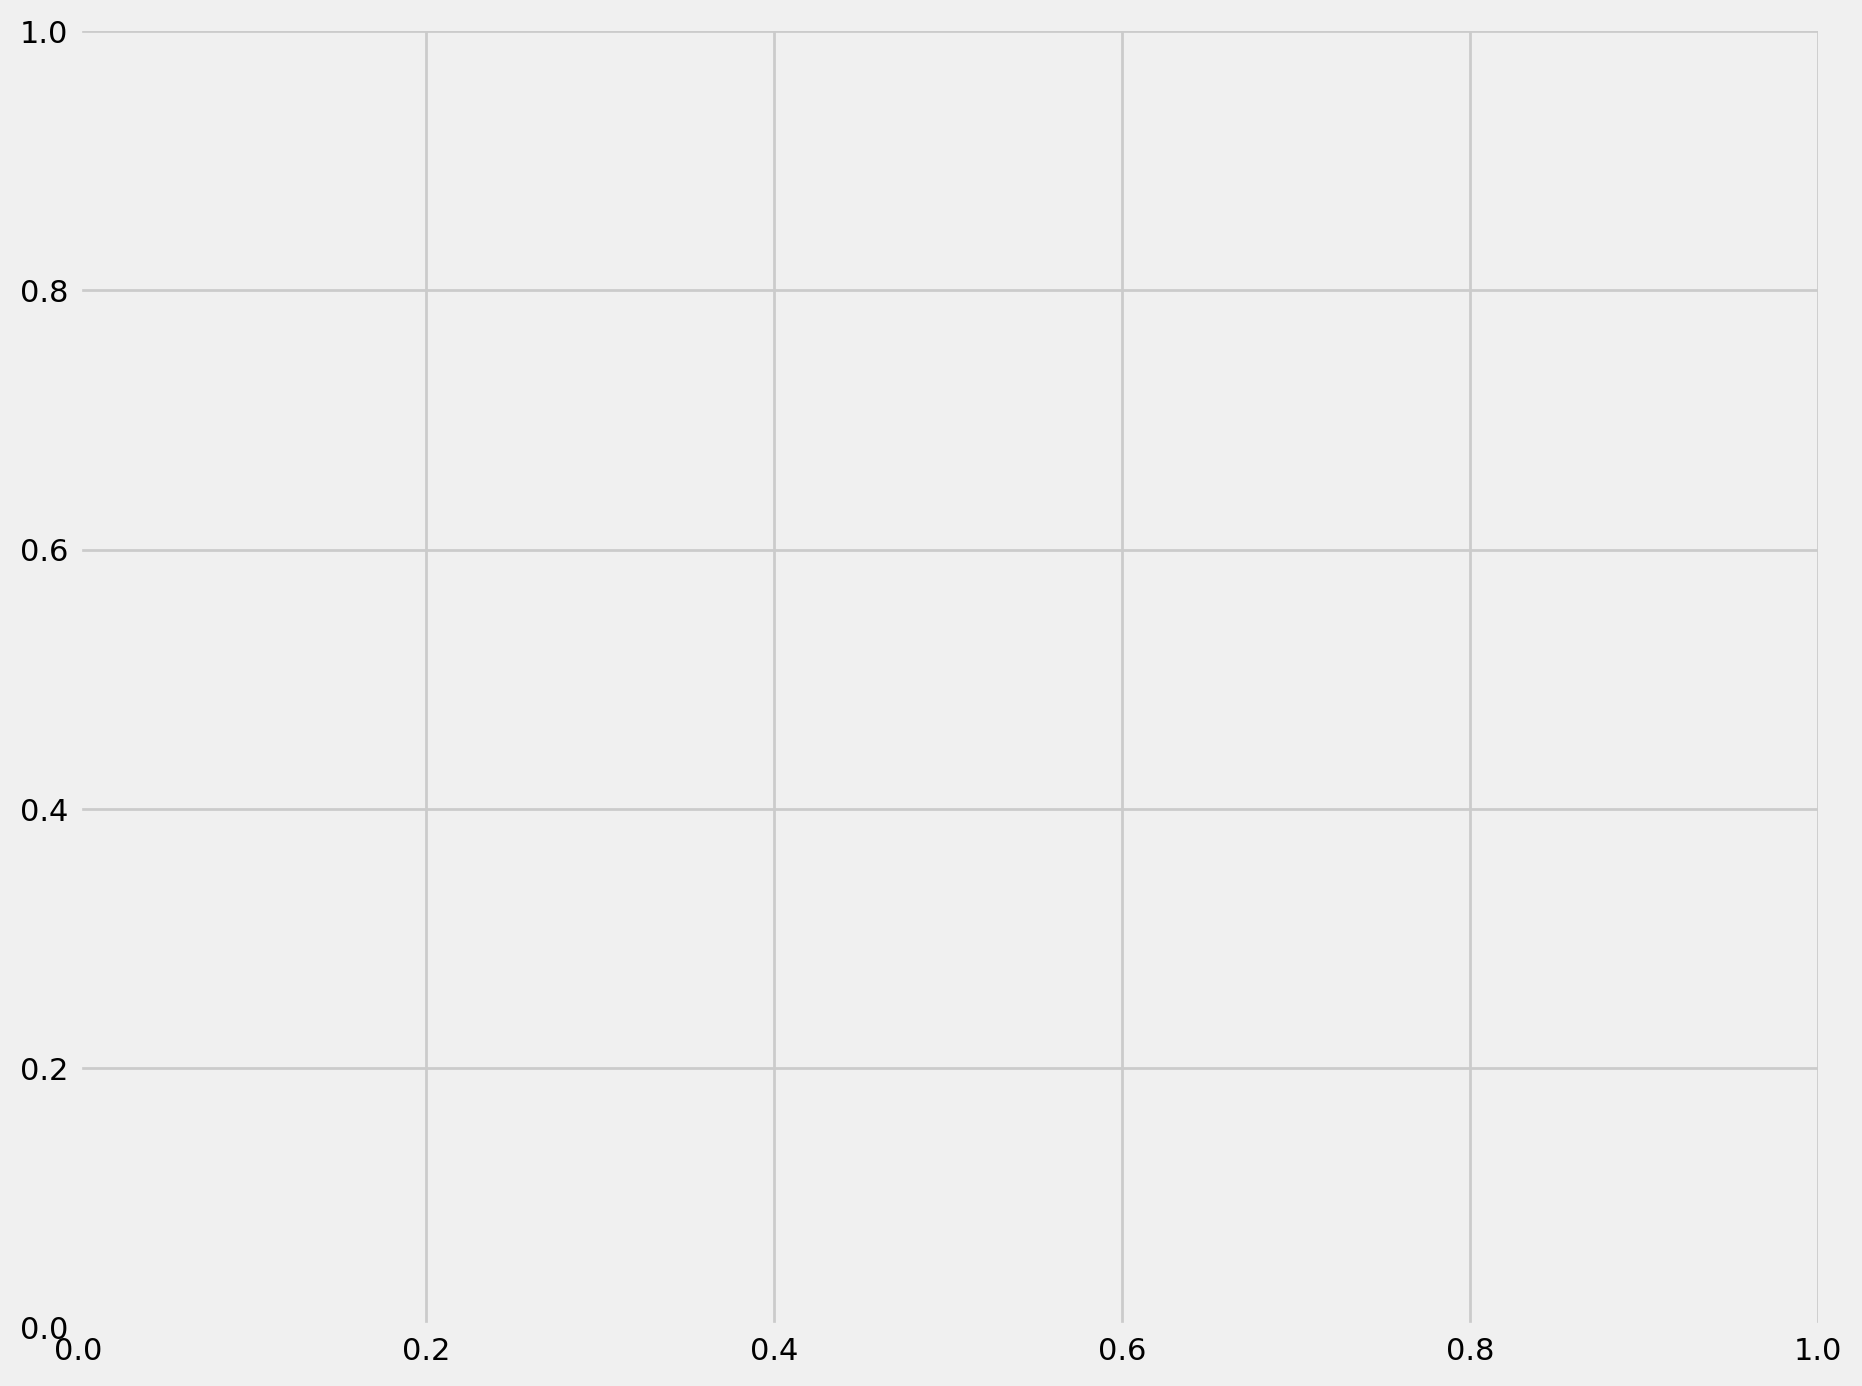

In [39]:
import numpy as np

numeric_cols_for_imputation = df.columns.difference(["country", "country_code", "year"])

fig, ax = plt.subplots(figsize=(10, 8))

unemp_basic_edu_idx = numeric_cols_for_imputation.get_loc('unemp_basic_edu') if 'unemp_basic_edu' in numeric_cols_for_imputation else -1
unemp_intermediate_edu_idx = numeric_cols_for_imputation.get_loc('unemp_intermediate_edu') if 'unemp_intermediate_edu' in numeric_cols_for_imputation else -1
unemp_adv_edu_idx = numeric_cols_for_imputation.get_loc('unemp_adv_edu') if 'unemp_adv_edu' in numeric_cols_for_imputation else -1

if unemp_basic_edu_idx == -1 or unemp_intermediate_edu_idx == -1 or unemp_adv_edu_idx == -1:
    raise ValueError("One or more required unemployment columns not found in numeric_cols_for_imputation.")

avg_basic = scaler.mean_[unemp_basic_edu_idx]
avg_inter = scaler.mean_[unemp_intermediate_edu_idx]
avg_adv = scaler.mean_[unemp_adv_edu_idx]

avg_basic = np.maximum(0, avg_basic)
avg_inter = np.maximum(0, avg_inter)
avg_adv = np.maximum(0, avg_adv)

sizes_outer = [avg_basic, avg_inter, avg_adv]
labels_outer = ['Basic Edu', 'Intermediate', 'Advanced']
colors_outer = ['#ff9999', '#66b3ff', '#99ff99']

sizes_inner = [avg_basic + avg_inter, avg_adv]
labels_inner = ['Non-Tertiary', 'Tertiary']
colors_inner = ['#c2c2f0', '#ffb3e6']

ax.pie(sizes_outer, labels=labels_outer, radius=1, colors=colors_outer,
       autopct='%1.1f%%', pctdistance=0.85,
       wedgeprops=dict(width=0.3, edgecolor='white'))

ax.pie(sizes_inner, radius=0.7, colors=colors_inner,
       autopct=None, wedgeprops=dict(width=0.3, edgecolor='white'))

ax.legend(labels_inner, loc='upper right', title="Broad Category")
plt.title("Composition of Unemployment by Education Level", fontsize=15)
plt.show()

### 2. Severity Comparison: Youth vs. General Unemployment vs. NEET

**Visual Overview:**
This Violin Plot compares the distribution density of three distinct categories. The "width" of the shape represents where the majority of countries are clustered, while the "height" shows the range of extreme values.

**Key Insights:**
*   **Disproportionate Impact on Youth:**
    *   The **Total Unemployment** violin (Left) is "short and wide" and sits lower on the Y-axis. This indicates that for the general population, unemployment is relatively low and stable across most developing countries.
    *   In contrast, the **Youth Unemployment** violin (Middle) is "tall and stretched." The median is significantly higher, and the long "neck" extending upward reveals that youth face a much more volatile labor market. In many nations, youth are 2x or 3x more likely to be unemployed than adults.
*   **The NEET Crisis:**
    *   The **NEET** violin (Right) shows a distribution similar to youth unemployment but often with a wider base. This quantifies the "lost generation"—youth who are economically inactive and at risk of long-term poverty.

### Arc Diagram (Correlations: Expenditure vs. Employment)

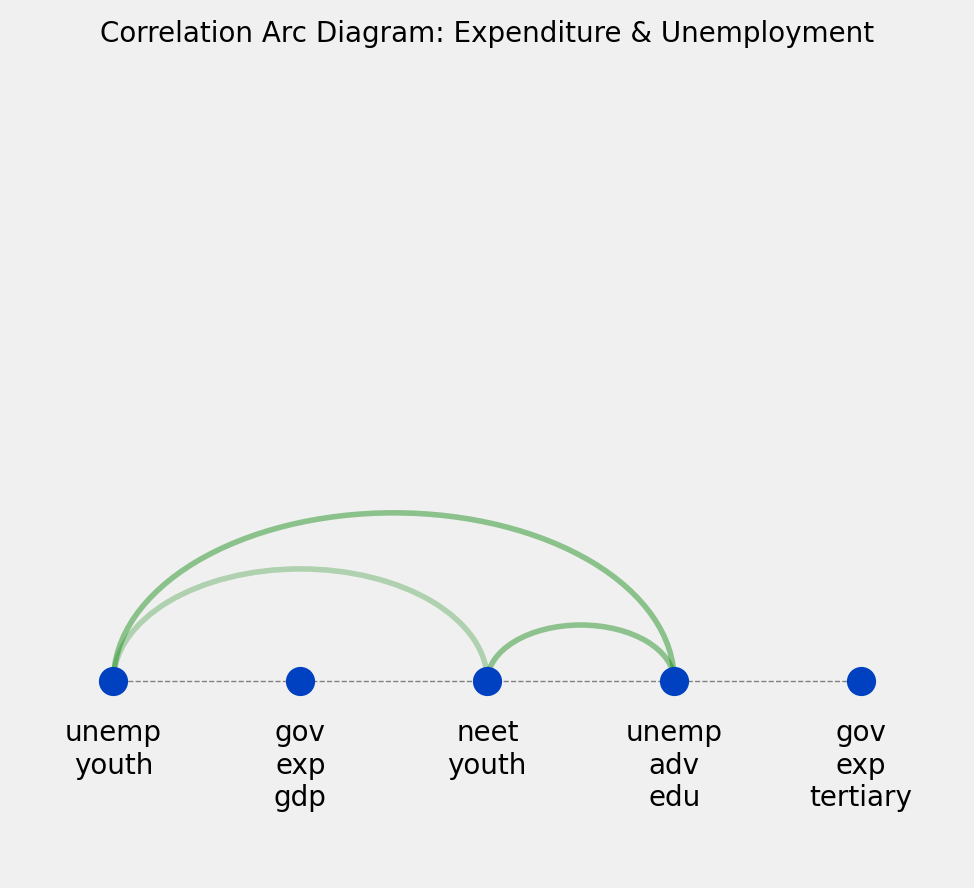

In [ ]:
import matplotlib.patches as patches
cols_interest = ['unemp_youth', 'gov_exp_gdp', 'neet_youth',
                 'unemp_adv_edu', 'gov_exp_tertiary']

corr_matrix = df[cols_interest].corr()
nodes = cols_interest
n_nodes = len(nodes)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_aspect('equal')

ax.scatter(range(n_nodes), [0]*n_nodes, s=100, zorder=2, color='#34495e')
for i, node in enumerate(nodes):
    label = node.replace('_', '\n')
    ax.text(i, -0.2, label, ha='center', va='top', fontsize=10)

ax.plot(range(n_nodes), [0]*n_nodes, color='gray', linestyle='--', linewidth=0.5, zorder=1)

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        var1 = nodes[i]
        var2 = nodes[j]
        corr_val = corr_matrix.loc[var1, var2]

        if abs(corr_val) > 0.2:
            color = 'green' if corr_val > 0 else '#d62728'

            center = ((i + j) / 2, 0)
            width = j - i
            height = width * 0.6

            arc = patches.Arc(xy=center, width=width, height=height,
                              theta1=0, theta2=180, color=color,
                              linewidth=2,
                              alpha=abs(corr_val)
                             )
            ax.add_patch(arc)

ax.set_xlim(-0.5, n_nodes - 0.5)
ax.set_ylim(-1, n_nodes/1.5)
ax.axis('off')
plt.title("Correlation Arc Diagram: Expenditure & Unemployment", fontsize=10)
plt.show()

### 1. Analysis of Variable Relationships (Arc Diagram)

**Visual Overview:**
This Arc Diagram illustrates the statistical correlations between key economic and social variables. Each node represents a variable (e.g., Government Expenditure, NEET Rate, Youth Unemployment), and the arcs represent a significant relationship between them.

**Key Insights:**
*   **The NEET-Unemployment Link:** The strong connection between `unemp_youth` and `neet_youth` confirms that as unemployment rises, the percentage of youth "Not in Education, Employment, or Training" also rises. This signals a risk of social exclusion; unemployed youth are likely to drop out of the system entirely rather than returning to education.
*   **Education Expenditure & Outcomes:** The arcs connecting Government Expenditure (`gov_exp_gdp` or `gov_exp_tertiary`) to the outcome variables are critical for policy analysis.
    *   If an arc is present, it suggests that fiscal policy has a measurable impact on employment figures.
    *   If the connection is weak or absent, it may indicate **fiscal inefficiency**—where money is being spent on education but is not effectively translating into jobs for graduates.

### Radial Bar Chart (Youth Unemployment by Country)

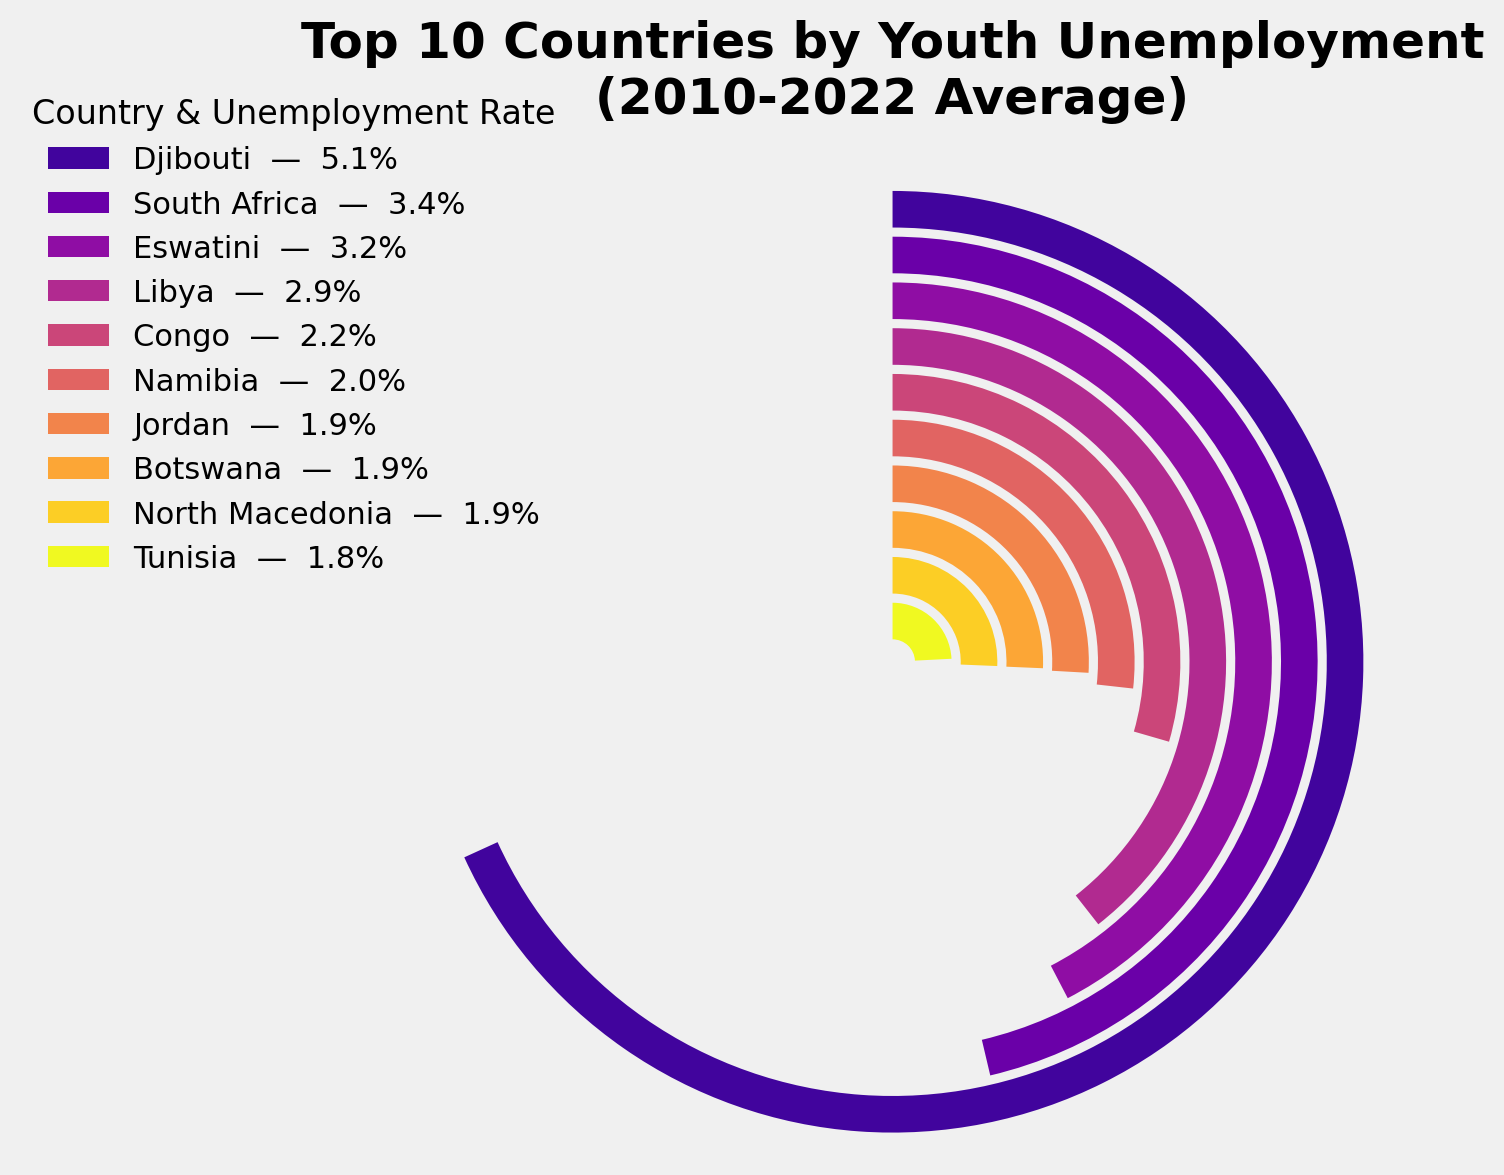

In [ ]:

df_grouped = df.groupby('country')['unemp_youth'].mean().reset_index()
top_countries = df_grouped.sort_values('unemp_youth', ascending=True).tail(10)

labels = top_countries['country'].values
values = top_countries['unemp_youth'].values
num_bars = len(labels)


fig, ax = plt.subplots(figsize=(8, 12), subplot_kw={'projection': 'polar'})

tracks = np.arange(num_bars) + 2
max_value = values.max() * 1.1
theta_values = (values / max_value) * (1.5 * np.pi)
colors = plt.cm.plasma_r(np.linspace(0, 0.9, num_bars))


bars = ax.barh(tracks, theta_values, height=0.8,
               color=colors, alpha=1.0, align='center')


legend_labels = [f"{country}  —  {val:.1f}%" for country, val in zip(labels, values)]

# Convert iterators to lists for the legend
handles_reversed = list(reversed(bars))
labels_reversed = list(reversed(legend_labels))


ax.legend(handles_reversed, labels_reversed,
          loc='upper left',           # Anchor point on the legend box
          bbox_to_anchor=(-0.4, 1.1), # Position relative to the plot (Top Left Corner)
          title="Country & Unemployment Rate",
          title_fontsize=12,
          fontsize=11,
          frameon=False)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.spines['polar'].set_visible(False)
ax.set_rticks([])
ax.set_xticks([])

plt.title("Top 10 Countries by Youth Unemployment\n(2010-2022 Average)",
          fontsize=18, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Geographical Hotspots: Top 10 Countries by Youth Unemployment

**Visual Overview:**
This Concentric Radial Bar Chart ranks the top 10 countries with the highest average youth unemployment rates from 2010 to 2022. The length of the bar corresponds to the magnitude of the unemployment rate, with the outermost ring representing the most severe case.

**Key Insights:**
*   **Regional Concentration:** A quick glance reveals a strong cluster of African nations (e.g., Djibouti, South Africa, Eswatini, Libya, Congo, Namibia, Botswana). This suggests that youth unemployment is not just a national issue but a **structural regional crisis** in Africa, likely driven by a "youth bulge" demographics where the population is growing faster than job creation.
*   **Magnitude of Disparity:** Djibouti (Outer Ring) leads with the highest rate. The visual gap between the outer rings and the inner rings (like Tunisia) highlights that even among the "worst performers," there is a significant difference in severity, requiring tailored intervention strategies for the most extreme cases.

 ## Box Plots for Unemployment by Education Level



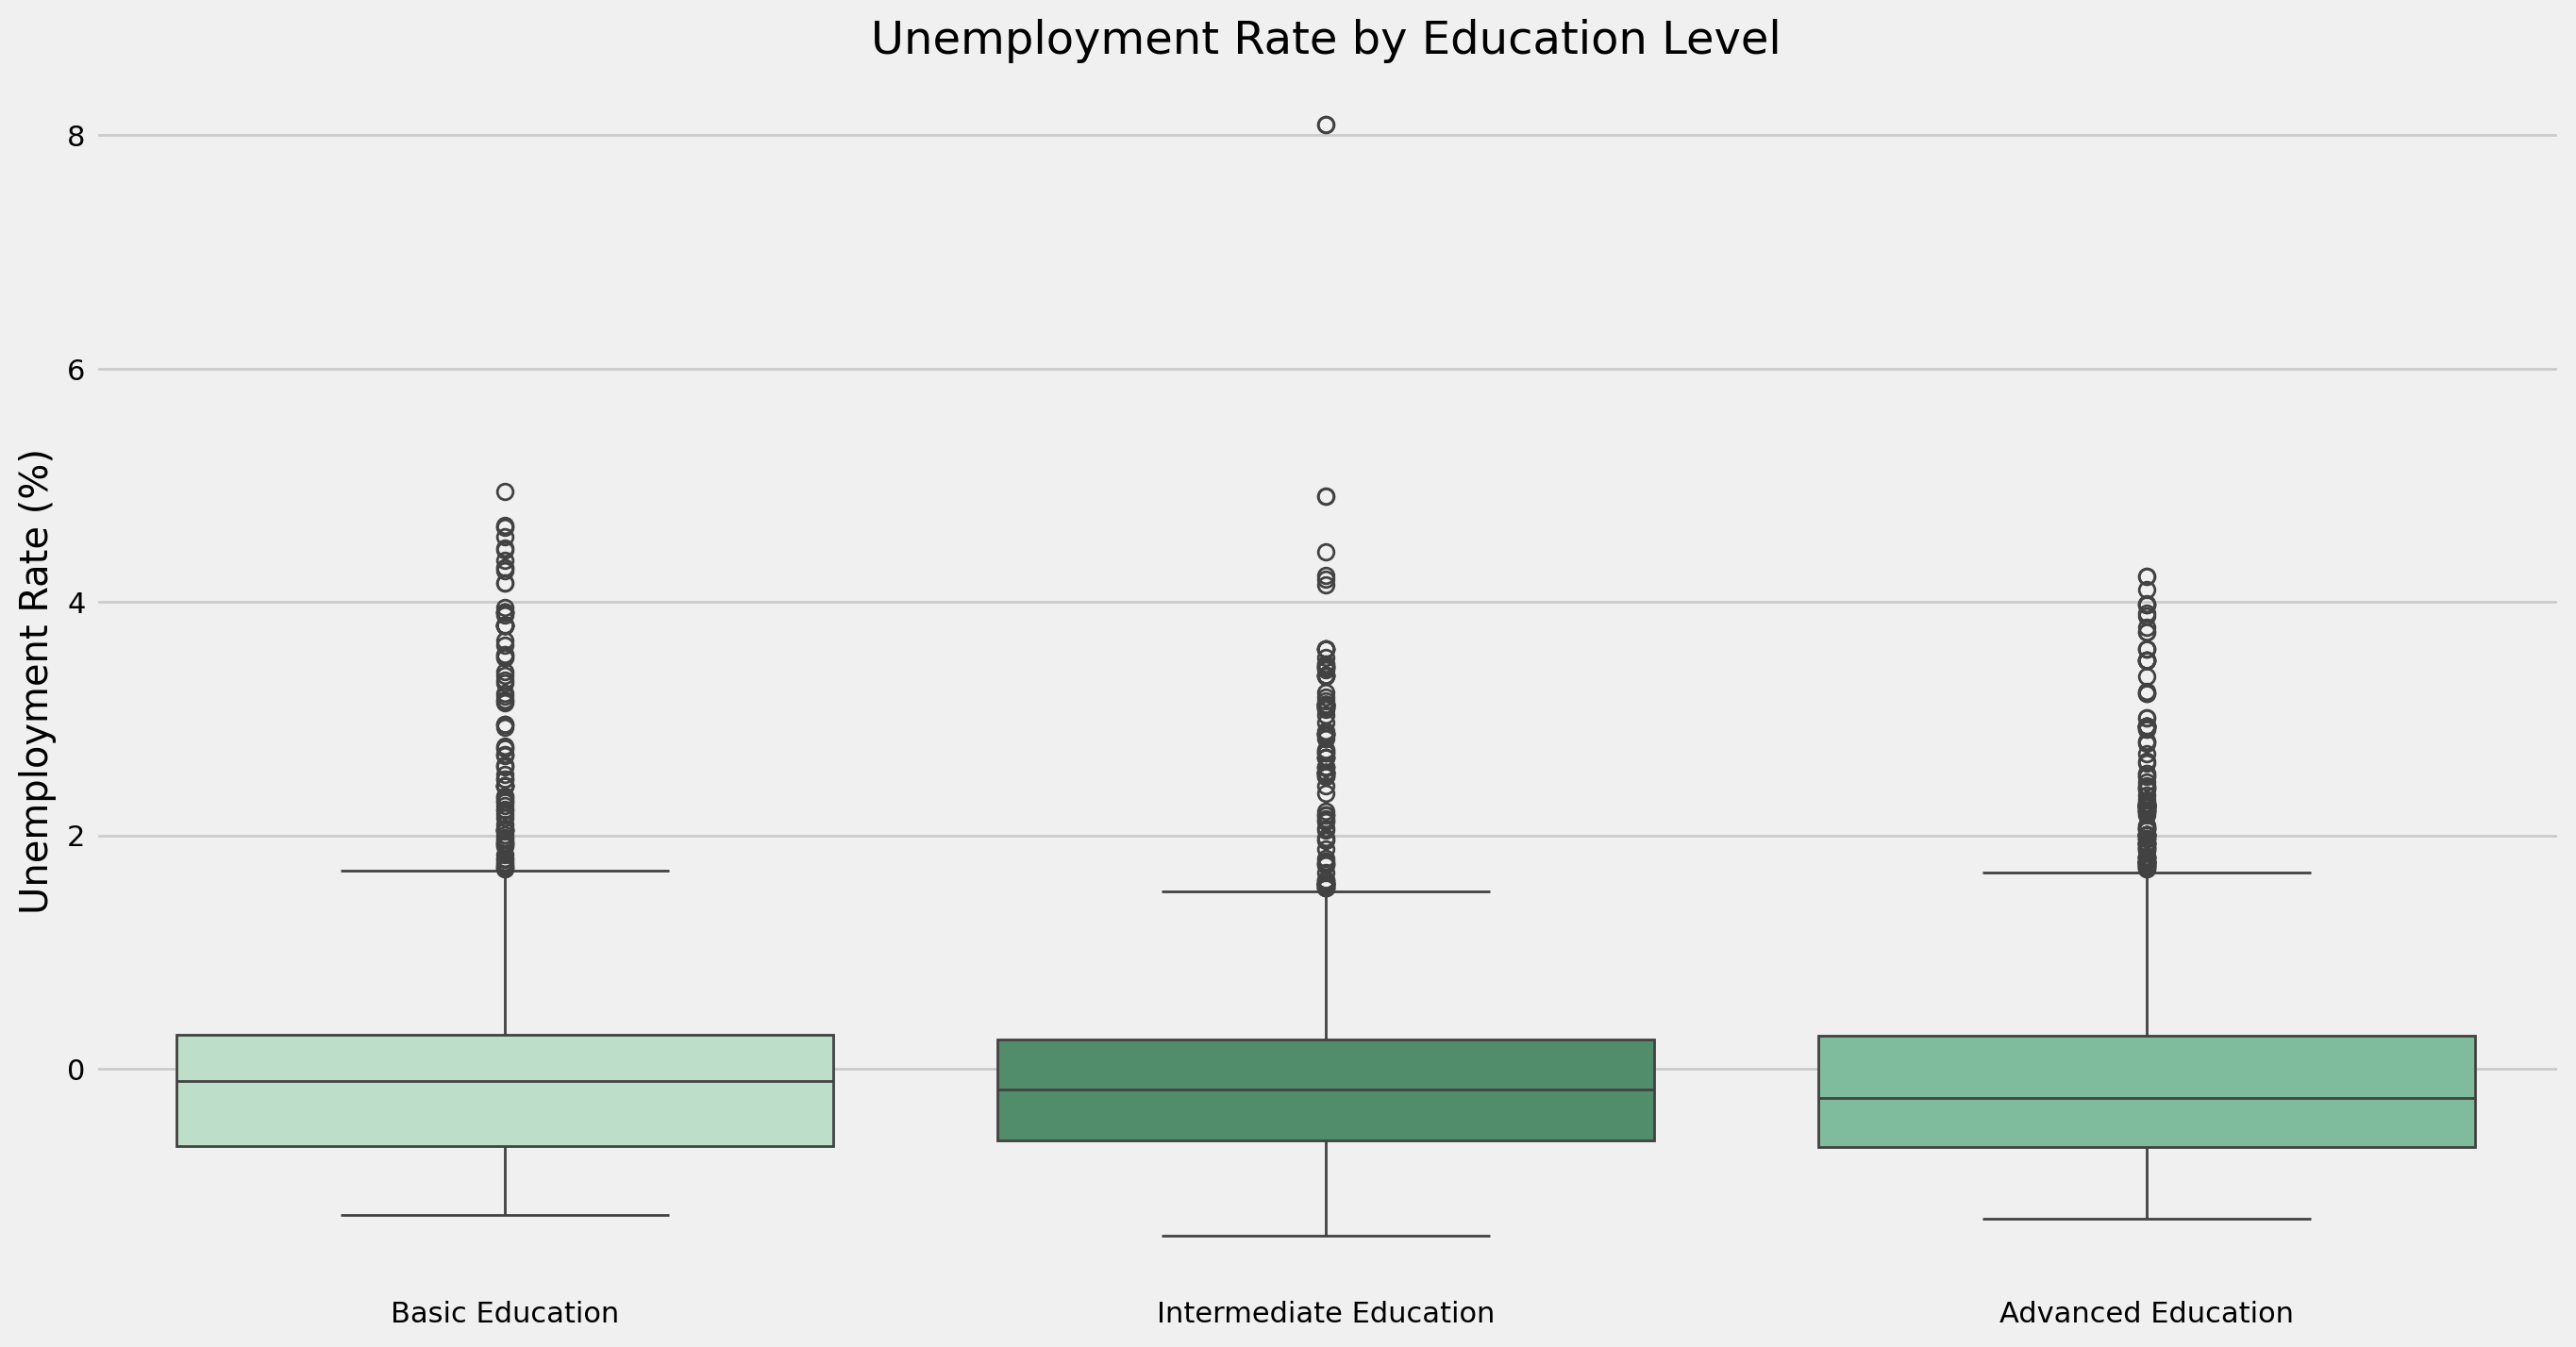

In [ ]:
# 5.
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['unemp_basic_edu', 'unemp_intermediate_edu', 'unemp_adv_edu']])
plt.title('Unemployment Rate by Education Level')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(ticks=[0,1,2], labels=['Basic Education', 'Intermediate Education', 'Advanced Education'])
plt.savefig('unemployment_by_education_boxplot.png')
plt.show()


### 4. The Paradox of Education: Unemployment by Education Level

**Visual Overview:**
This Box Plot analyzes whether higher education guarantees employment. It displays the distribution of unemployment rates for three labor force segments: Basic, Intermediate, and Advanced education.

**Key Insights:**
*   **The "Skills Mismatch" Phenomenon:**
    *   Ideally, we would expect the "Advanced Education" box to be much lower than the "Basic Education" box. However, the chart shows significant overlap between the groups.
    *   The presence of numerous **outliers (circles)** above the top whisker in the **Advanced Education** category is alarming. It indicates that in many developing countries, university graduates face exceptionally high unemployment rates.
*   **Policy Implication:** This supports the theory that the economy is not creating enough white-collar/high-skill jobs to absorb the supply of graduates. It suggests that simply increasing university enrollment without fixing labor market demand may lead to a surplus of "educated unemployed" youth.

## Multivariate

### 3D Scatterplot

In [40]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np


size_raw = df['labor_adv_edu'].astype(float).to_numpy()
size_shifted = size_raw - np.nanmin(size_raw)
if np.nanmax(size_shifted) == 0 or np.isnan(np.nanmax(size_shifted)):
    size_norm = np.ones_like(size_shifted)
else:
    size_norm = size_shifted / np.nanmax(size_shifted)
size_scaled = 5 + 25 * size_norm

fig = px.scatter_3d(
    df,
    x='gov_exp_gdp',
    y='attain_bachelors',
    z='unemp_youth',
    color='unemp_total',
    size=size_scaled,
    hover_data=['country', 'year'],
    color_continuous_scale=custom_palette,
    title="3D Scatter: Government Spending vs Education vs Youth Unemployment",
    labels={
        'gov_exp_gdp': 'Gov Education Spending (% GDP)',
        'attain_bachelors': 'Bachelors Attainment (%)',
        'unemp_youth': 'Youth Unemployment (%)',
        'unemp_total': 'Total Unemployment (%)',
        'labor_adv_edu': 'Adv Education Labor (%)'
    }
)
fig.update_layout(width=900, height=700)
fig.show()

### 3D Scatter Plot

This 3D scatter plot shows three important things about developing countries from 2015-2024:
- **X-axis (left-right)**: Government Education Spending as a percentage of GDP (`gov_exp_gdp`) - how much of the country's total economic output is spent on education
- **Y-axis (front-back)**: Bachelors Attainment percentage (`attain_bachelors`) - what percentage of people aged 25+ have at least a bachelor's degree
- **Z-axis (up-down)**: Youth Unemployment rate (`unemp_youth`) - the percentage of young people (ages 15-24) who are unemployed

**What the Colors and Sizes Mean:**
- **Color**: The color of each dot shows the **Total Unemployment rate** (`unemp_total`) for that country. Darker green shades mean higher total unemployment across all age groups.
- **Size**: The size of each dot shows the **Labor Force with Advanced Education** percentage (`labor_adv_edu`) - how many working-age people have advanced education. Bigger dots mean more highly educated workers in the labor force.

**Interpretation:**
- Each dot represents one country in one specific year
- If you see dots clustered together, it means those countries have similar patterns in education spending, degree attainment, and youth unemployment
- Dots that are far apart mean those countries are very different in these measures


### Heatmap

In [41]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'year' in numeric_cols:
    numeric_cols.remove('year')

corr_matrix = df[numeric_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='YlGnBu',
    aspect="auto",
    title="Correlation Heatmap: Relationships Between Variables",
    labels=dict(color="Correlation")
)
fig.update_layout(width=1000, height=900)
fig.show()

### Heatmap

This heatmap shows the relationships (correlations) between all the different variables in our dataset. Each square in the grid shows how two variables are connected.

**Interpretation:**
- **Color intensity**: Darker colors (blue) mean a stronger relationship. Lighter colors mean a weaker relationship.
- **Red colors**: Usually mean the variables move in opposite directions (when one goes up, the other goes down)
- **Blue colors**: Usually mean the variables move together (when one goes up, the other goes up too)
- **The diagonal line**: This line from top-left to bottom-right shows each variable compared to itself (always perfect correlation, so it's usually the darkest color)






### Bubble Chart


In [42]:

fig = px.scatter(
    df,
    x='gov_exp_gdp',
    y='unemp_youth',
    size=size_scaled,
    color='exp_tertiary',
    animation_frame='year',
    animation_group='country',
    hover_name='country',
    hover_data=['unemp_total', 'labor_adv_edu'],
    color_continuous_scale='Turbo',
    size_max=50,
    title="Animated Bubble Chart: Education Spending vs Youth Unemployment Over Time",
    labels={
        'gov_exp_gdp': 'Government Education Spending (% GDP)',
        'unemp_youth': 'Youth Unemployment (%)',
        'attain_bachelors': 'Bachelors Attainment (%)',
        'exp_tertiary': 'Tertiary Education Expenditure (%)'
    },
    range_x=[df['gov_exp_gdp'].min() * 0.9, df['gov_exp_gdp'].max() * 1.1],
    range_y=[df['unemp_youth'].min() * 0.9, df['unemp_youth'].max() * 1.1]
)
fig.update_layout(width=1000, height=700)
fig.show()

### Bubble Chart

This animated bubble chart shows how developing countries change over time from 2015 to 2024:
- **X-axis**: Government Education Spending as a percentage of GDP (`gov_exp_gdp`) - how much the country invests in education relative to its economy
- **Y-axis**: Youth Unemployment rate (`unemp_youth`) - the percentage of young people (15-24) who can't find jobs
- **Bubble size**: The size of each bubble shows the **Labor Force with Advanced Education** percentage (`labor_adv_edu`) - bigger bubbles mean more highly educated workers in that country's labor force
- **Bubble color **: The color shows **Tertiary Education Expenditure** percentage (`exp_tertiary`) - how much is spent on university-level education. The Turbo scale goes from dark (low spending) to bright colors (high spending)

**Interpretation:**
- Each bubble represents one country in one specific year
- The position of the bubble shows where that country stands on the spending vs. unemployment spectrum
- Bigger bubbles mean that country has more people with advanced education in their workforce
- The chart is **animated by year**

**What to Look For:**
- **Bottom-left corner**: Countries with low education spending AND low youth unemployment (very efficient - getting good results with less money)
- **Top-right corner**: Countries with high education spending BUT high youth unemployment (inefficient - spending a lot but not seeing results)
- **Bottom-right corner**: Countries with high spending AND low unemployment (ideal situation - investment paying off)
- **Clusters**: Groups of bubbles together mean countries with similar situations



### Radar/Spider Plot

In [43]:
import plotly.graph_objects as go

countries_to_compare = ['Pakistan', 'India', 'Bangladesh', 'Brazil', 'South Africa']
comparison_vars = ['unemp_youth', 'gov_exp_gdp', 'attain_bachelors',
                   'exp_tertiary', 'labor_adv_edu', 'neet_youth']

def normalize_for_radar(series):
    return ((series - series.min()) / (series.max() - series.min())) * 100

fig = go.Figure()

for country in countries_to_compare:
    country_data = df[df['country'] == country].groupby('country')[comparison_vars].mean().iloc[0]
    normalized = normalize_for_radar(country_data)

    fig.add_trace(go.Scatterpolar(
        r=normalized.values,
        theta=[var.replace('_', ' ').title() for var in comparison_vars],
        fill='toself',
        name=country
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100])
    ),
    showlegend=True,
    title="Radar Chart: Multi-Dimensional Country Comparison",
    height=700
)
fig.show()

### Radar Plot (Spider Chart)

This radar plot compares five different countries (Pakistan, India, Bangladesh, Brazil, and South Africa) across six different measures:
- Youth unemployment rate
- Government education spending (as % of GDP)
- Bachelor's degree attainment
- Tertiary education expenditure
- Advanced education in labor force
- NEET youth (Not in Education, Employment, or Training)

**Interpretation:**
- Each "spoke" (line from center to edge) represents one measure
- Each colored shape represents one country
- The further the shape extends toward the edge on a spoke, the better that country is doing in that measure
- The closer to the center, the worse that country is doing

**Shape Analysis:**
- **Large, even shape**: A country doing well across all measures
- **Small shape**: A country struggling in most areas
- **Irregular shape**: A country doing well in some areas but poorly in others
- **Overlapping shapes**: Countries with similar performance

### Tree Diagrams

In [44]:

country_stats = df.groupby('country').agg({
    'unemp_youth': 'mean',
    'gov_exp_gdp': 'mean',
    'attain_bachelors': 'mean'
}).reset_index()

fig = px.treemap(
    country_stats,
    path=['country'],
    values='unemp_youth',
    color='gov_exp_gdp',
    color_continuous_scale=custom_divergent,
    hover_data=['attain_bachelors'],
    title="Treemap: Countries by Youth Unemployment (Size) and Gov Spending (Color)"
)
fig.update_layout(width=1200, height=800)
fig.show()

 ### Treemap Visualization

The treemap below provides a hierarchical view of countries based on multiple variables simultaneously. This visualization helps identify patterns and relationships in the data through both size and color encoding.

- **Rectangle Size**: The size of each country's rectangle represents the average youth unemployment rate. Larger rectangles indicate higher unemployment rates.

- **Rectangle Color**: The color intensity represents government expenditure on education as a percentage of GDP. Darker colors indicate higher spending.

- **Hover Information**: When you hover over a country, you can see additional details including bachelor's degree attainment rates.




## Maps

In [45]:

df_sorted = df.sort_values(["country", "year"])

numeric_cols = df_sorted.select_dtypes("number").columns.tolist()
for col in ["year"]:  
    if col in numeric_cols:
        numeric_cols.remove(col)

default_metric = numeric_cols[0]

fig = px.choropleth(
    df_sorted,
    locations="country",
    locationmode="country names",
    color=default_metric,
    hover_name="country",
    color_continuous_scale=custom_divergent,
    animation_frame="year",      
    title=f"Global Map: {default_metric.replace('_', ' ').title()}",
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=col.replace("_", " ").title(),
                    method="update",
                    args=[
                        {"z": [df_sorted[col]]},   # update color metric
                        {
                            "coloraxis": {
                                "colorbar": {"title": col.replace("_", " ").title()}
                            },
                            "title": f"Global Map: {col.replace('_', ' ').title()}"
                        },
                    ],
                )
                for col in numeric_cols
            ],
            direction="down",
            showactive=True,
            x=1.05,
            y=0.8,
        )
    ],
    margin=dict(r=10),
)


fig.show()

/var/folders/93/8hnxl0g54g16dnr19w2v_4t80000gn/T/ipykernel_14392/2135960334.py:10: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [46]:

df_sorted = df.sort_values(["country", "year"])
latest = df_sorted.groupby("country").tail(1)

numeric_cols = latest.select_dtypes("number").columns.tolist()
for col in ["year"]:
    if col in numeric_cols:
        numeric_cols.remove(col)

fig = px.choropleth(
    latest,
    locations="country",
    locationmode="country names",
    color=numeric_cols[0],
    hover_name="country",
    color_continuous_scale=custom_divergent ,
    title=f"Global Map: {numeric_cols[0].replace('_', ' ').title()}",
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=col.replace("_", " ").title(),
                    method="update",
                    args=[
                        {"z": [latest[col]]},
                        {"coloraxis": {"colorbar": {"title": col.replace('_',' ').title()}},
                         "title": f"Global Map: {col.replace('_',' ').title()}"}
                    ],
                )
                for col in numeric_cols
            ],
            direction="down",
            showactive=True,
            x=1.05,
            y=0.8,
        )
    ],
    margin=dict(r=150),
)

fig.show()

/var/folders/93/8hnxl0g54g16dnr19w2v_4t80000gn/T/ipykernel_14392/1708059892.py:9: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



## Conclusion

1) Youth face disproportionate unemployment: Young
people are 2–3 times more likely to be unemployed
than the general population, indicating a systemic issue
affecting this demographic group.

2) Regional concentration in Africa: The highest youth
unemployment rates are concentrated in African nations,
suggesting structural regional challenges that require
coordinated regional responses.

3) Education paradox: Advanced education does not
guarantee employment, revealing a skills mismatch be-
tween educational output and labor market demand.

4) NEET crisis: High unemployment correlates strongly
with disengagement from both education and employ-
ment, creating risks of long-term economic exclusion.

5) Policy inefficiency: Government education expenditure
does not always translate into improved employment
outcomes, indicating the need for better coordination
between education and economic policies.
 
B. Policy Recommendations
Based on these findings, we recommend:
* Job creation focus: Policies should prioritize creating
employment opportunities, particularly in sectors that can
absorb educated youth
* Education quality and relevance: Reform education
systems to align curricula with labor market demands and
improve quality rather than just increasing enrollment
* Regional cooperation: African nations should coordinate
youth employment strategies given the regional nature of
the crisis
* Targeted interventions: Develop country-specific strate-
gies based on local economic structures and labor market
conditions
* NEET prevention: Implement programs to prevent un-
employed youth from disengaging entirely from educa-
tion and training systems